<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB
None
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0

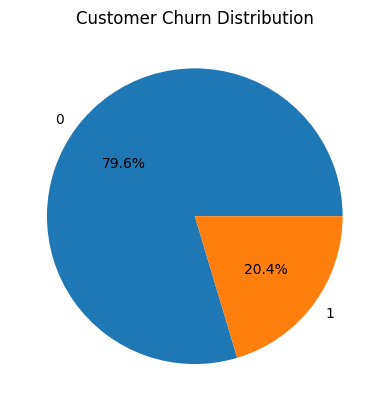

(10000, 14)
Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')


Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


In [59]:
import pandas as pd

df = pd.read_csv("../data/European_Bank.csv")

df.head()

print(df.info())

print(df.isnull().sum())

print(df.describe())

df.isnull().sum()

df["Exited"].value_counts()

import matplotlib.pyplot as plt

df["Exited"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Customer Churn Distribution")
plt.show()

print(df.shape)

print(df.columns)

df["Geography"].value_counts()

pd.crosstab(df["Geography"], df["Exited"], normalize="index") * 100


In [60]:
pd.crosstab(df["IsActiveMember"], df["Exited"], normalize="index") * 100 

Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074


In [61]:
pd.crosstab(df["NumOfProducts"], df["Exited"], normalize="index") * 100

Exited,0,1
NumOfProducts,,
1,72.285602,27.714398
2,92.418301,7.581699
3,17.293233,82.706767
4,0.000000,100.000000


In [62]:
pd.crosstab(df["HasCrCard"], df["Exited"], normalize="index") * 100

Exited,0,1
HasCrCard,,
0,79.185059,20.814941
1,79.815734,20.184266


In [63]:
pd.crosstab(df["Gender"], df["Exited"], normalize="index") * 100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


In [64]:
df.groupby("Exited")["Age"].mean()

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

In [65]:
df.groupby("Exited")["Balance"].mean()

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

In [66]:
df.groupby("Exited")["EstimatedSalary"].mean()

Exited
0     99738.391772
1    101465.677531
Name: EstimatedSalary, dtype: float64

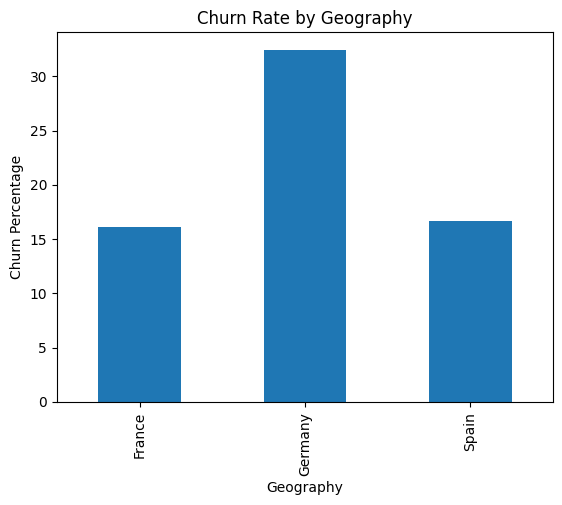

In [67]:
import matplotlib.pyplot as plt

churn_geo = pd.crosstab(df["Geography"], df["Exited"], normalize="index") * 100

churn_geo[1].plot(kind="bar")

plt.title("Churn Rate by Geography")
plt.ylabel("Churn Percentage")
plt.show()

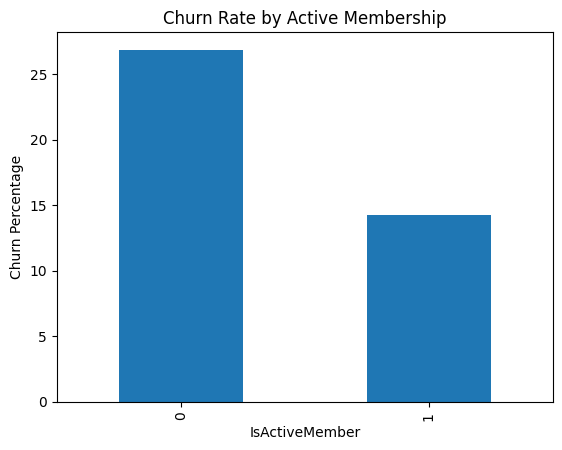

In [68]:
active_churn = pd.crosstab(df["IsActiveMember"], df["Exited"], normalize="index") * 100

active_churn[1].plot(kind="bar")

plt.title("Churn Rate by Active Membership")
plt.ylabel("Churn Percentage")
plt.show()

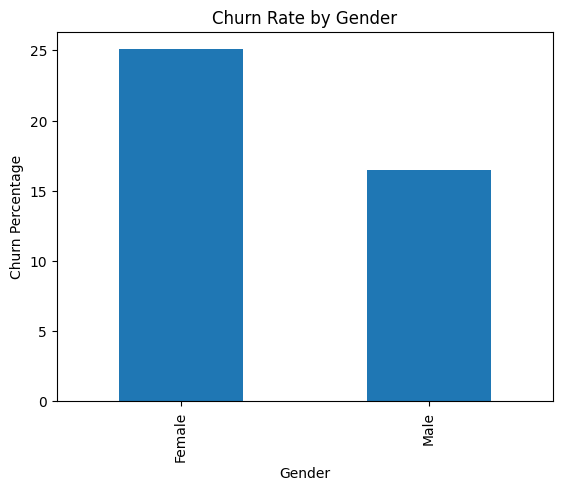

In [69]:
gender_churn = pd.crosstab(df["Gender"], df["Exited"], normalize="index") * 100

gender_churn[1].plot(kind="bar")

plt.title("Churn Rate by Gender")
plt.ylabel("Churn Percentage")
plt.show()

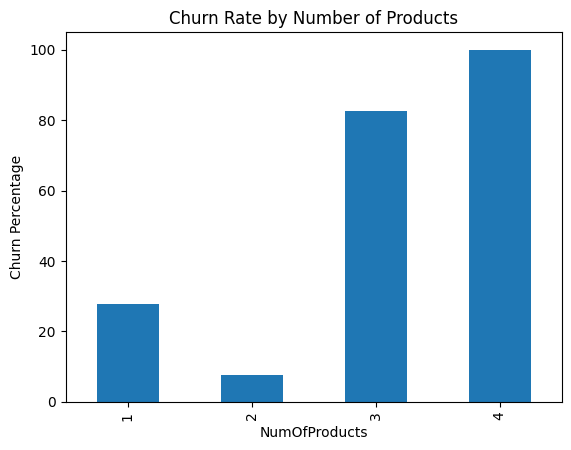

In [70]:
product_churn = pd.crosstab(df["NumOfProducts"], df["Exited"], normalize="index") * 100

product_churn[1].plot(kind="bar")

plt.title("Churn Rate by Number of Products")
plt.ylabel("Churn Percentage")
plt.show()

In [71]:
high_value_customers = df[
    (df["Balance"] > df["Balance"].median()) &
    (df["IsActiveMember"] == 0)
]

print("Number of disengaged high-value customers:", len(high_value_customers))

high_value_customers[
    ["CustomerId", "Balance", "EstimatedSalary", "Exited"]
].head(10)

Number of disengaged high-value customers: 2456


,CustomerId,Balance,EstimatedSalary,Exited
2,15619304,159660.80,113931.57,1
5,15574012,113755.78,149756.71,1
7,15656148,115046.74,119346.88,1
10,15767821,102016.72,80181.12,0
16,15737452,132602.88,5097.67,1
32,15750181,110112.54,81898.81,0
35,15794171,134264.04,27822.99,1
41,15738148,122522.32,181297.65,1
43,15755196,131394.56,194365.76,1
49,15771873,103769.22,194099.12,0


In [72]:
active_low_product = df[
    (df["IsActiveMember"] == 1) &
    (df["NumOfProducts"] == 1)
]

print("Active but low-product customers:", len(active_low_product))

active_low_product[
    ["CustomerId", "NumOfProducts", "Balance", "Exited"]
].head(10)

Active but low-product customers: 2563


,CustomerId,NumOfProducts,Balance,Exited
0,15634602,1,0.00,1
1,15647311,1,83807.86,0
4,15737888,1,125510.82,0
9,15592389,1,134603.88,0
24,15625047,1,0.00,0
26,15736816,1,136815.64,0
28,15728693,1,141349.43,0
31,15706552,1,85311.70,0
36,15788448,1,145260.23,0
37,15729599,1,76548.60,0


In [73]:
salary_balance_mismatch = df[
    (df["EstimatedSalary"] > df["EstimatedSalary"].median()) &
    (df["Balance"] < df["Balance"].median())
]

print("Salary-Balance Mismatch Customers:", len(salary_balance_mismatch))

salary_balance_mismatch[
    ["CustomerId", "EstimatedSalary", "Balance", "Exited"]
].head(10)

Salary-Balance Mismatch Customers: 2484


,CustomerId,EstimatedSalary,Balance,Exited
0,15634602,101348.88,0.00,1
1,15647311,112542.58,83807.86,0
13,15691483,190857.79,0.00,0
18,15661507,158684.81,0.00,0
20,15577657,170886.17,0.00,0
21,15597945,138555.46,0.00,0
22,15699309,118913.53,0.00,1
24,15625047,187616.16,0.00,0
25,15738191,124508.29,0.00,0
30,15589475,140469.38,0.00,1


In [74]:
sticky_customers = df[
    (df["IsActiveMember"] == 1) &
    (df["NumOfProducts"] >= 2) &
    (df["Exited"] == 0)
]

print("Sticky Customers:", len(sticky_customers))

sticky_customers[
    ["CustomerId", "NumOfProducts", "Balance", "Exited"]
].head(10)

Sticky Customers: 2338


,CustomerId,NumOfProducts,Balance,Exited
6,15592531,2,0.00,0
8,15792365,2,142051.07,0
14,15600882,2,0.00,0
15,15643966,2,143129.41,0
17,15788218,2,0.00,0
19,15568982,2,0.00,0
20,15577657,2,0.00,0
23,15725737,2,0.00,0
25,15738191,2,0.00,0
29,15656300,2,59697.17,0


In [75]:
df["RelationshipStrength"] = (
    df["IsActiveMember"] +
    (df["NumOfProducts"] >= 2).astype(int)
)

pd.crosstab(
    df["RelationshipStrength"],
    df["Exited"],
    normalize="index"
) * 100

Exited,0,1
RelationshipStrength,,
0,63.347878,36.652122
1,82.355347,17.644653
2,90.340031,9.659969


Final Conclusions

1. Germany has the highest churn rate (32.44%).
2. Inactive customers are more likely to churn than active customers.
3. Customers with 2 products show the lowest churn rate.
4. Female customers have a higher churn rate than male customers.
5. Older customers are more likely to leave the bank.
6. Credit card ownership has little impact on churn.
7. Estimated salary is not a major factor affecting churn.